Working dir: /home/chplay2020/src/vn-yhct-rag/rag-yhct
Collection: yhct_chunks_v2_full_emb
Vectors config: {'size': 1024, 'distance': 'Cosine'}
Payload schema keys: ['is_noise', 'parent_id', 'child_index', 'category', 'doc_type']
Vector dim: 1024
Scanned points: 27284, sampled: 1000
Sample matrix: (1000, 1024)
Norm stats: {'min': 0.9999998807907104, 'p25': 0.9999999403953552, 'median': 1.0, 'p75': 1.0, 'max': 1.0000001192092896, 'mean': 0.9999999817609787, 'std': 3.064652670340337e-08}
Pairwise cosine stats: {'min': 0.18486882746219635, 'p05': 0.3478598892688751, 'p25': 0.41796866059303284, 'median': 0.47282618284225464, 'p75': 0.532939612865448, 'p95': 0.6261045336723328, 'max': 1.000000238418579, 'mean': 0.4780169725418091, 'std': 0.08445359021425247}
Nearest-neighbor cosine stats: {'p05': 0.6138536334037781, 'p25': 0.6796677112579346, 'median': 0.7260543704032898, 'p75': 0.7733958959579468, 'p95': 0.8656072616577148, 'mean': 0.730122447013855}
✅ No strong collapse signal (heuristic)

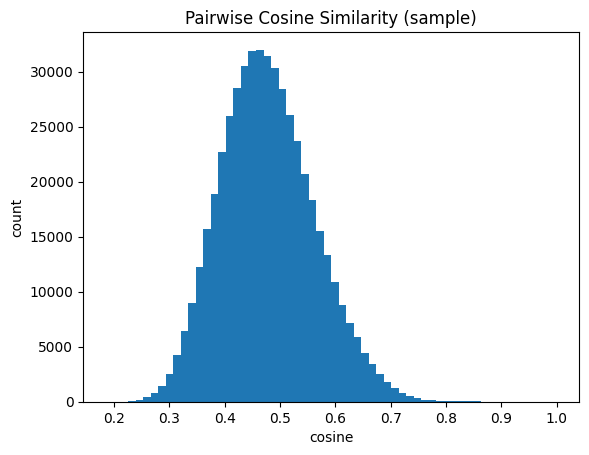

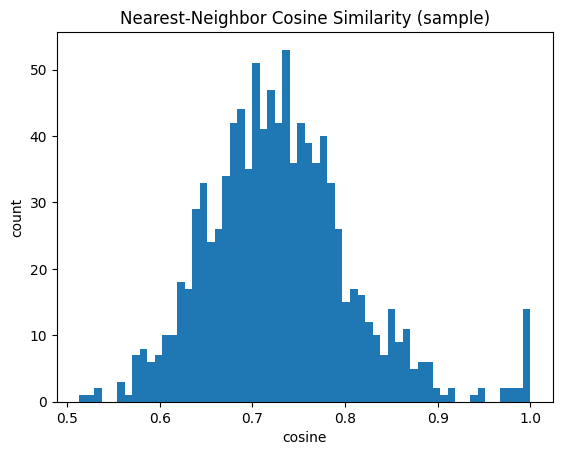

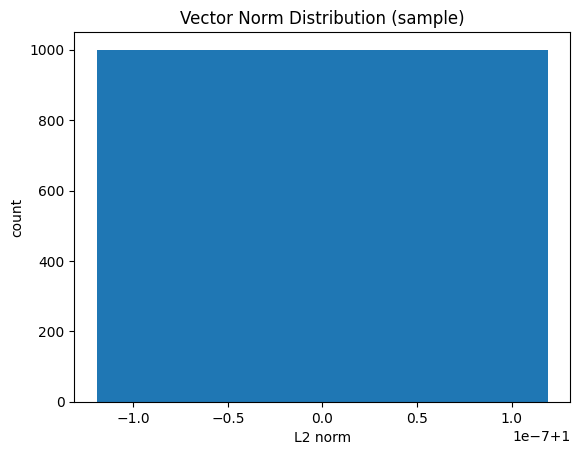

norm range: 2.384185791015625e-07
norm min/max: 0.9999998807907104 1.0000001192092896
KMeans inertia: 435.0257263183594
Cluster sizes: Counter({np.int32(3): 151, np.int32(9): 146, np.int32(0): 121, np.int32(8): 116, np.int32(5): 110, np.int32(6): 97, np.int32(2): 90, np.int32(1): 63, np.int32(7): 63, np.int32(4): 43})
    cluster doc_type       category  \
0         3      txt    MY_MI_DUONG   
1         3      txt    MY_MI_DUONG   
2         3      txt  GiaoKhoaVeYCT   
3         3      txt         YEUCAU   
4         3      txt       SACHYHCT   
5         3      txt    MY_MI_DUONG   
6         9      txt    MY_MI_DUONG   
7         9      txt    MY_MI_DUONG   
8         9      txt    MY_MI_DUONG   
9         9      txt    MY_MI_DUONG   
10        9      txt    MY_MI_DUONG   
11        9      txt    MY_MI_DUONG   
12        0      txt  GiaoKhoaVeYCT   
13        0      txt    MY_MI_DUONG   
14        0      txt    MY_MI_DUONG   
15        0      txt    MY_MI_DUONG   
16        0      

/home/chplay2020/.pyenv/versions/3.11.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chplay2020/.pyenv/versions/3.11.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D projection: UMAP (3000, 2)


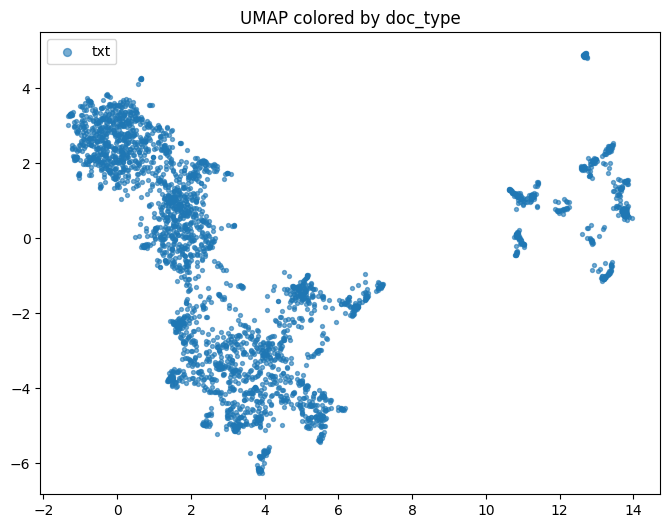

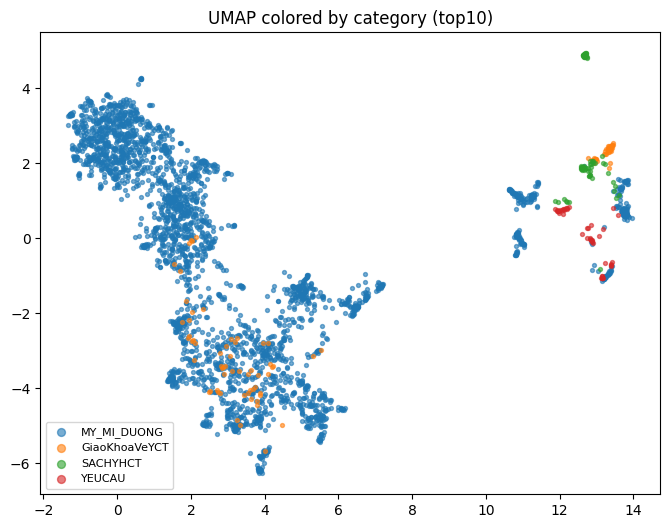

Sampled for synthetic: 120
Generated QA: 120
[{'question': 'Quá trình tách các alcaloid từ thuốc phiện trong hình 17.3 gồm bao nhiêu bước?', 'expected_chunk_id': 'src_92a6ae24adf8:677faed4cb8a'}, {'question': 'Mô tả cây Sâm cau bao gồm những đặc điểm nào?', 'expected_chunk_id': 'src_d5596b1dce93:552952de4b89'}, {'question': 'Đoạn nào trong đoạn văn nói về các loại kháng sinh có hoạt tính khi dùng uống và tiêm?', 'expected_chunk_id': 'src_4aa8d7a49009:0ff3a3364e00'}]
Embed dim: 1024 Qdrant dim: 1024
Hit@5: 0.475 (57/120)
MRR: 0.353
Failures: 63
[{'q': 'Đoạn nào trong đoạn văn nói về các loại kháng sinh có hoạt tính khi dùng uống và tiêm?', 'expected': 'src_4aa8d7a49009:0ff3a3364e00', 'got': ['src_02172872945b:d705a29acbbf', 'src_4aa8d7a49009:540784b07eee', 'src_4aa8d7a49009:a9b6a71bdd4a', 'src_e0520ddfd9ac:317cb36b5ee5', 'src_d5596b1dce93:317cb36b5ee5'], 'rank': None}, {'q': 'Cần lưu ý điều gì khi sử dụng vỏ cây?', 'expected': 'src_d5596b1dce93:8c59a9788e48', 'got': ['src_d5596b1dce93:e

In [1]:
# %%
# ====================== 0) CONFIG ======================
QDRANT_URL = "http://localhost:6333"
COLLECTION = "yhct_chunks_v2_full_emb"

# VECTOR_NAME:
# - Nếu collection là single-vector: để None (Qdrant trả key "vector": [...])
# - Nếu collection là named-vector: set "default" (Qdrant trả "vector": {"default":[...]}).
VECTOR_NAME = None

SAMPLE_N = 1000           # sample vectors để tính similarity
VIS_N = 3000              # sample vectors để vẽ UMAP/TSNE (giảm nếu máy yếu)

CHUNKS_JSONL = "data/chunks/chunks_v2_full.jsonl"

# Synthetic eval
SYN_N = 120
SYN_TOPK = 5
ONLY_NON_NOISE = True
MIN_TEXT_LEN = 200

# LLM generate question
import os
_PROJECT_ROOT = os.path.abspath(
    os.path.join(os.path.dirname(__file__) if "__file__" in dir() else os.getcwd(), "..")
)
if os.path.basename(os.getcwd()) == "tests":
    os.chdir(os.path.join(os.getcwd(), ".."))
elif not os.path.isdir("data"):
    _candidate = os.path.join(os.getcwd(), "rag-yhct")
    if os.path.isdir(_candidate):
        os.chdir(_candidate)

print("Working dir:", os.getcwd())

LLM_BACKEND = "ollama"    # "ollama" | "manual"
OLLAMA_URL = "http://localhost:11434"
OLLAMA_CHAT_MODEL = "qwen2.5:7b-instruct"   # đổi đúng model bạn có

# Embedding (PHẢI match embedding bạn dùng để upsert Qdrant)
EMBED_BACKEND = "ollama"
OLLAMA_EMBED_MODEL = "bge-m3"               # đổi đúng model embedding đã index (dim phải khớp)

SEED = 42

# %%
# ====================== 1) Imports + Helpers ======================
import json, time, random, re
from collections import Counter
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # pyright: ignore
import requests  # pyright: ignore

random.seed(SEED)
np.random.seed(SEED)

def qget(path: str) -> Dict[str, Any]:
    r = requests.get(f"{QDRANT_URL}{path}", timeout=120)  # pyright: ignore
    r.raise_for_status()
    return r.json()

def qpost(path: str, payload: Dict[str, Any]) -> Dict[str, Any]:
    r = requests.post(f"{QDRANT_URL}{path}", json=payload, timeout=300)  # pyright: ignore
    r.raise_for_status()
    return r.json()

def ensure_dir(p: str) -> None:
    os.makedirs(p, exist_ok=True)

def extract_vector(point: Dict[str, Any]) -> Optional[np.ndarray]:
    """
    Qdrant scroll/search trả vector ở:
    - point["vector"] = [...] (single)
    - point["vector"] = {"default":[...]} (named)
    """
    if "vector" in point and point["vector"] is not None:
        v = point["vector"]
        if isinstance(v, dict):
            if VECTOR_NAME and VECTOR_NAME in v:
                return np.array(v[VECTOR_NAME], dtype=np.float32)
            return np.array(next(iter(v.values())), dtype=np.float32)
        return np.array(v, dtype=np.float32)

    if "vectors" in point and point["vectors"] is not None:
        v = point["vectors"]
        if isinstance(v, dict):
            if VECTOR_NAME and VECTOR_NAME in v:
                return np.array(v[VECTOR_NAME], dtype=np.float32)
            return np.array(next(iter(v.values())), dtype=np.float32)

    return None

def parse_category(file_path: Optional[str]) -> str:
    """
    Lấy category sau '/TT_YHCT/' trong path:
    data/raw/<zip>/TT_YHCT/<CATEGORY>/...
    """
    if not file_path:
        return "unknown"
    s = file_path.replace("\\", "/")
    m = re.search(r"/TT_YHCT/([^/]+)/", s)
    return m.group(1) if m else "unknown"

def short_text(pl: Dict[str, Any], n: int = 180) -> str:
    t = pl.get("text_norm") or pl.get("text") or ""
    t = re.sub(r"\s+", " ", t).strip()
    return (t[:n] + "…") if len(t) > n else t

# ✅ FIX TRIỆT ĐỂ: safe_bins "siêu lì"
def safe_bins(data: np.ndarray, desired: int = 60):
    """
    Robust bins chooser:
    - Nếu data range quá nhỏ => trả 1 bin (không crash).
    - Check cả float64 và float32 (vì edges có thể collapse do rounding).
    """
    a64 = np.asarray(data, dtype=np.float64)
    lo64 = float(np.min(a64))
    hi64 = float(np.max(a64))

    if (not np.isfinite(lo64)) or (not np.isfinite(hi64)) or hi64 <= lo64:
        return 1

    lo32 = np.float32(lo64)
    hi32 = np.float32(hi64)
    if (not np.isfinite(lo32)) or (not np.isfinite(hi32)) or hi32 <= lo32:
        return 1

    # thử tạo edges float32, nếu trùng edges => 1 bin
    edges32 = np.linspace(lo32, hi32, desired + 1, dtype=np.float32)
    if np.unique(edges32).size < edges32.size:
        return 1

    # guard range cực nhỏ theo scale
    rng = hi64 - lo64
    scale = max(1.0, abs(float(np.mean(a64))))
    if rng < 1e-12 * scale:
        return 1

    return desired

def safe_hist(arr: np.ndarray, title: str, xlabel: str):
    """hist không bao giờ crash: fallback bins=1"""
    plt.figure()
    try:
        plt.hist(arr, bins=safe_bins(arr))
    except ValueError:
        plt.hist(arr, bins=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.show()

# %%
# ====================== 2) Collection info (dim + payload schema/index) ======================
info = qget(f"/collections/{COLLECTION}")
cfg = info.get("result", {}).get("config", {}).get("params", {}).get("vectors", None)
payload_schema = info.get("result", {}).get("payload_schema", None)

print("Collection:", COLLECTION)
print("Vectors config:", cfg)
print("Payload schema keys:", list(payload_schema.keys()) if isinstance(payload_schema, dict) else payload_schema)

def get_dim(cfg: Any) -> Optional[int]:
    if cfg is None:
        return None
    # single vector
    if isinstance(cfg, dict) and "size" in cfg:
        return cfg["size"]
    # named vectors
    if isinstance(cfg, dict):
        if VECTOR_NAME and VECTOR_NAME in cfg and isinstance(cfg[VECTOR_NAME], dict):
            return cfg[VECTOR_NAME].get("size")
        first = next(iter(cfg.values()), None)
        if isinstance(first, dict):
            return first.get("size")
    return None

VECTOR_DIM = get_dim(cfg)
print("Vector dim:", VECTOR_DIM)

# %%
# ====================== 3) Reservoir sampling points from Qdrant ======================
def reservoir_sample_points(
    sample_n: int,
    with_vectors: bool = True,
    with_payload: bool = True,
    flt: Optional[Dict[str, Any]] = None,
) -> List[Dict[str, Any]]:
    limit = 256
    offset = None
    seen = 0
    sample: List[Dict[str, Any]] = []

    while True:
        body: Dict[str, Any] = {"limit": limit, "with_vector": with_vectors, "with_payload": with_payload}
        if offset is not None:
            body["offset"] = offset
        if flt is not None:
            body["filter"] = flt

        res = qpost(f"/collections/{COLLECTION}/points/scroll", body)
        pts = res.get("result", {}).get("points", [])
        offset = res.get("result", {}).get("next_page_offset", None)

        if not pts:
            break

        for p in pts:
            seen += 1
            if len(sample) < sample_n:
                sample.append(p)
            else:
                j = random.randint(1, seen)
                if j <= sample_n:
                    sample[j - 1] = p

        if offset is None:
            break

    print(f"Scanned points: {seen}, sampled: {len(sample)}")
    return sample

pts = reservoir_sample_points(SAMPLE_N, with_vectors=True, with_payload=True, flt=None)

vectors, payloads = [], []
for p in pts:
    v = extract_vector(p)
    if v is None:
        continue
    vectors.append(v)
    payloads.append(p.get("payload", {}))

X = np.vstack(vectors).astype(np.float32)
print("Sample matrix:", X.shape)
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

# %%
# ====================== 4) Vector health: norms + pairwise cosine + nearest neighbor ======================
norms = np.linalg.norm(X, axis=1).astype(np.float64)  # cast float64 để ổn định bins
print("Norm stats:", {
    "min": float(np.min(norms)),
    "p25": float(np.percentile(norms, 25)),
    "median": float(np.median(norms)),
    "p75": float(np.percentile(norms, 75)),
    "max": float(np.max(norms)),
    "mean": float(np.mean(norms)),
    "std": float(np.std(norms)),
})

S = (Xn @ Xn.T).astype(np.float32)
np.fill_diagonal(S, np.nan)

triu = S[np.triu_indices_from(S, k=1)]
triu = triu[~np.isnan(triu)]

print("Pairwise cosine stats:", {
    "min": float(np.min(triu)),
    "p05": float(np.percentile(triu, 5)),
    "p25": float(np.percentile(triu, 25)),
    "median": float(np.median(triu)),
    "p75": float(np.percentile(triu, 75)),
    "p95": float(np.percentile(triu, 95)),
    "max": float(np.max(triu)),
    "mean": float(np.mean(triu)),
    "std": float(np.std(triu)),
})

nn = np.nanmax(S, axis=1)
print("Nearest-neighbor cosine stats:", {
    "p05": float(np.percentile(nn, 5)),
    "p25": float(np.percentile(nn, 25)),
    "median": float(np.median(nn)),
    "p75": float(np.percentile(nn, 75)),
    "p95": float(np.percentile(nn, 95)),
    "mean": float(np.mean(nn)),
})

if np.mean(triu) > 0.85 and np.percentile(triu, 95) > 0.93:
    print("⚠️ Possible vector collapse (heuristic).")
else:
    print("✅ No strong collapse signal (heuristic).")

# %%
# ====================== 5) Plots: histograms (KHÔNG BAO GIỜ CRASH) ======================
safe_hist(triu, "Pairwise Cosine Similarity (sample)", "cosine")
safe_hist(nn, "Nearest-Neighbor Cosine Similarity (sample)", "cosine")
safe_hist(norms, "Vector Norm Distribution (sample)", "L2 norm")

print("norm range:", float(np.max(norms) - np.min(norms)))
print("norm min/max:", float(np.min(norms)), float(np.max(norms)))

# %%
# ====================== 6) K-Means clustering (K=10) + inspect samples per cluster ======================
K = 10
try:
    from sklearn.cluster import KMeans  # pyright: ignore
    km = KMeans(n_clusters=K, n_init="auto", random_state=SEED)  # pyright: ignore
    labels = km.fit_predict(Xn)  # pyright: ignore
    print("KMeans inertia:", float(km.inertia_))
except Exception as e:
    print("KMeans failed:", e)
    labels = np.random.randint(0, K, size=Xn.shape[0])

sizes = Counter(labels)
print("Cluster sizes:", sizes)

rows = []
for lab, count in sizes.most_common():
    idxs = np.where(labels == lab)[0][:6]
    for idx in idxs:
        pl = payloads[int(idx)]
        rows.append({
            "cluster": int(lab),
            "doc_type": pl.get("doc_type"),
            "category": parse_category(pl.get("file_path")),
            "title": pl.get("title"),
            "chunk_id": pl.get("chunk_id"),
            "text_sample": short_text(pl),
        })

df_clusters = pd.DataFrame(rows)
print(df_clusters.head(20))
df_clusters

# %%
# ====================== 7) UMAP / t-SNE / PCA visualization ======================
pts_vis = reservoir_sample_points(VIS_N, with_vectors=True, with_payload=True, flt=None)

V, P = [], []
for p in pts_vis:
    v = extract_vector(p)
    if v is None:
        continue
    V.append(v)
    P.append(p.get("payload", {}))

V = np.vstack(V).astype(np.float32)
Vn = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

labels_doc = [pl.get("doc_type", "unknown") for pl in P]
labels_cat = [parse_category(pl.get("file_path")) for pl in P]

method_used = None
Z = None
try:
    import umap  # pyright: ignore
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)  # pyright: ignore
    Z = reducer.fit_transform(Vn)  # pyright: ignore
    method_used = "UMAP"
except Exception as e:
    print("UMAP not available:", e)
    try:
        from sklearn.manifold import TSNE  # pyright: ignore
        Z = TSNE(
            n_components=2,
            perplexity=30,
            init="pca",
            learning_rate="auto",
            random_state=SEED
        ).fit_transform(Vn)  # pyright: ignore
        method_used = "t-SNE"
    except Exception as e2:
        print("t-SNE not available:", e2)
        from sklearn.decomposition import PCA  # pyright: ignore
        Z = PCA(n_components=2, random_state=SEED).fit_transform(Vn)  # pyright: ignore
        method_used = "PCA"

print("2D projection:", method_used, Z.shape if Z is not None else None)

if Z is not None:
    plt.figure(figsize=(8, 6))
    for dt in sorted(set(labels_doc)):
        m = np.array([x == dt for x in labels_doc])
        plt.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.6, label=dt)
    plt.title(f"{method_used} colored by doc_type")
    plt.legend(markerscale=2)
    plt.show()

    top_cats = [c for c, _ in Counter(labels_cat).most_common(10)]
    plt.figure(figsize=(8, 6))
    for cat in top_cats:
        m = np.array([x == cat for x in labels_cat])
        plt.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.6, label=cat)
    plt.title(f"{method_used} colored by category (top10)")
    plt.legend(markerscale=2, fontsize=8)
    plt.show()

# %%
# ====================== 8) Synthetic Ground Truth Retrieval Eval (Hit@K, MRR) ======================
def iter_jsonl(path: str):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)

def sample_chunks_for_synth(n: int) -> List[Dict[str, Any]]:
    pool = []
    for r in iter_jsonl(CHUNKS_JSONL):
        if ONLY_NON_NOISE and r.get("is_noise") is True:
            continue
        t = (r.get("text_norm") or r.get("text") or "").strip()
        if len(t) < MIN_TEXT_LEN:
            continue
        pool.append(r)
    random.shuffle(pool)
    return pool[:n]

cand = sample_chunks_for_synth(SYN_N)
print("Sampled for synthetic:", len(cand))

def ollama_chat(prompt: str) -> str:
    url = f"{OLLAMA_URL}/api/chat"
    payload = {
        "model": OLLAMA_CHAT_MODEL,
        "messages": [
            {"role": "system", "content": "Bạn là trợ lý tạo câu hỏi. Trả lời đúng 1 câu hỏi, không giải thích."},
            {"role": "user", "content": prompt},
        ],
        "stream": False,
    }
    r = requests.post(url, json=payload, timeout=300)  # pyright: ignore
    r.raise_for_status()
    return r.json()["message"]["content"].strip()

def gen_question(text: str) -> str:
    prompt = (
        "Dựa vào đoạn văn sau, hãy tạo 1 câu hỏi ngắn bằng tiếng Việt mà câu trả lời nằm hoàn toàn trong đoạn này. "
        "Chỉ trả về câu hỏi, không giải thích.\n\n"
        f"ĐOẠN VĂN:\n{text}"
    )
    if LLM_BACKEND == "ollama":
        return ollama_chat(prompt)
    print(text[:600])
    return input("Nhập câu hỏi: ").strip()

qa = []
for r in cand:
    q = gen_question((r.get("text_norm") or r.get("text") or "")[:1800])
    qa.append({"question": q, "expected_chunk_id": r["chunk_id"]})
print("Generated QA:", len(qa))
print(qa[:3])

# %%
# ====================== 8.1) Embedding + Qdrant search ======================
def ollama_embed(text: str) -> List[float]:
    url = f"{OLLAMA_URL}/api/embeddings"
    payload = {"model": OLLAMA_EMBED_MODEL, "prompt": text}
    r = requests.post(url, json=payload, timeout=300)  # pyright: ignore
    r.raise_for_status()
    emb = r.json().get("embedding")
    if emb is None:
        raise RuntimeError("Ollama embeddings returned no embedding. Check OLLAMA_EMBED_MODEL.")
    return emb

def embed(text: str) -> np.ndarray:
    if EMBED_BACKEND != "ollama":
        raise RuntimeError("Chỉ cấu hình ollama trong script này.")
    return np.array(ollama_embed(text), dtype=np.float32)

def qdrant_search(vec: np.ndarray, limit: int = 5, flt: Optional[Dict[str, Any]] = None) -> List[Dict[str, Any]]:
    body: Dict[str, Any] = {"limit": limit, "with_payload": True, "with_vector": False}
    if VECTOR_NAME:
        body["vector"] = {VECTOR_NAME: vec.tolist()}
    else:
        body["vector"] = vec.tolist()
    if flt is not None:
        body["filter"] = flt
    res = qpost(f"/collections/{COLLECTION}/points/search", body)
    return res.get("result", [])

vtest = embed("kiểm tra chiều vector")
print("Embed dim:", len(vtest), "Qdrant dim:", VECTOR_DIM)
if VECTOR_DIM and len(vtest) != VECTOR_DIM:
    raise ValueError(
        f"Embedding dim mismatch: embed={len(vtest)} vs qdrant={VECTOR_DIM}. "
        f"Đổi OLLAMA_EMBED_MODEL đúng cái bạn dùng để upsert."
    )

flt_eval = {"must": [{"key": "is_noise", "match": {"value": False}}]} if ONLY_NON_NOISE else None

hits, rr_sum = 0, 0.0
detail = []
for item in qa:
    q = item["question"]
    exp = item["expected_chunk_id"]
    qv = embed(q)
    res = qdrant_search(qv, limit=SYN_TOPK, flt=flt_eval)
    got = [r.get("payload", {}).get("chunk_id") for r in res]

    rank = None
    for i, cid in enumerate(got, start=1):
        if cid == exp:
            rank = i
            break
    if rank is not None:
        hits += 1
        rr_sum += 1.0 / rank

    detail.append({"q": q, "expected": exp, "got": got, "rank": rank})

hit_rate = hits / max(1, len(qa))
mrr = rr_sum / max(1, len(qa))
print(f"Hit@{SYN_TOPK}: {hit_rate:.3f} ({hits}/{len(qa)})")
print(f"MRR: {mrr:.3f}")

fails = [d for d in detail if d["rank"] is None]
print("Failures:", len(fails))
print(fails[:5])

# %%
# ====================== 9) Payload filter integrity + speed ======================
p1 = pts_vis[0]
v1 = extract_vector(p1)
assert v1 is not None

def timed_search(flt: Optional[Dict[str, Any]], n: int = 12) -> Dict[str, float]:
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        _ = qdrant_search(v1, limit=10, flt=flt)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)
    return {
        "median_ms": float(np.median(times)),
        "p90_ms": float(np.percentile(times, 90)),
        "min_ms": float(np.min(times)),
        "max_ms": float(np.max(times)),
    }

no_f = timed_search(None)
flt_txt_non_noise = {
    "must": [
        {"key": "doc_type", "match": {"value": "txt"}},
        {"key": "is_noise", "match": {"value": False}},
    ]
}
with_f = timed_search(flt_txt_non_noise)

print("Search time no-filter:", no_f)
print("Search time filter(doc_type=txt,is_noise=false):", with_f)

res = qdrant_search(v1, limit=5, flt=flt_txt_non_noise)
print("doc_type:", [r.get("payload", {}).get("doc_type") for r in res])
print("is_noise:", [r.get("payload", {}).get("is_noise") for r in res])

info2 = qget(f"/collections/{COLLECTION}")
print("payload_schema:", info2.get("result", {}).get("payload_schema"))

# %%
# ====================== 10) Save report JSON ======================
report = {
    "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "collection": COLLECTION,
    "vector_dim": VECTOR_DIM,
    "sample_n": int(X.shape[0]),
    "norm_stats": {
        "min": float(np.min(norms)),
        "p25": float(np.percentile(norms, 25)),
        "median": float(np.median(norms)),
        "p75": float(np.percentile(norms, 75)),
        "max": float(np.max(norms)),
        "mean": float(np.mean(norms)),
        "std": float(np.std(norms)),
    },
    "pairwise_cosine_stats": {
        "min": float(np.min(triu)),
        "p05": float(np.percentile(triu, 5)),
        "p25": float(np.percentile(triu, 25)),
        "median": float(np.median(triu)),
        "p75": float(np.percentile(triu, 75)),
        "p95": float(np.percentile(triu, 95)),
        "max": float(np.max(triu)),
        "mean": float(np.mean(triu)),
        "std": float(np.std(triu)),
    },
    "nearest_neighbor_cosine_stats": {
        "p05": float(np.percentile(nn, 5)),
        "p25": float(np.percentile(nn, 25)),
        "median": float(np.median(nn)),
        "p75": float(np.percentile(nn, 75)),
        "p95": float(np.percentile(nn, 95)),
        "mean": float(np.mean(nn)),
    },
    "synthetic_eval": {"n": len(qa), "topk": SYN_TOPK, "hit_rate": float(hit_rate), "mrr": float(mrr)},
    "search_speed_ms": {"no_filter": no_f, "filter_txt_non_noise": with_f},
}

ensure_dir("data/reports")
out_path = "data/reports/h1_vector_quality_report.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("Saved:", out_path)
print(report)

In [2]:
import json

CHUNKS_JSONL = "data/chunks/chunks_v2_full.jsonl"

# map chunk_id -> parent_id, source_id
cid2parent = {}
cid2source = {}
with open(CHUNKS_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        cid = r.get("chunk_id")
        if not cid:
            continue
        cid2parent[cid] = r.get("parent_id")
        cid2source[cid] = r.get("source_id")

def source_of(cid: str):
    # fallback: parse src_... from chunk_id
    return cid2source.get(cid) or (cid.split(":", 1)[0] if ":" in cid else None)

def parent_of(cid: str):
    return cid2parent.get(cid)

def hash_of(cid: str):
    # suffix sau dấu ":" thường là hash
    return cid.split(":", 1)[1] if ":" in cid else cid

TOPK = 5
n = len(detail)

hit_source = 0
hit_parent = 0
hit_hash = 0

for d in detail:
    exp = d["expected"]
    got = d["got"][:TOPK]

    exp_source = source_of(exp)
    exp_parent = parent_of(exp)
    exp_hash = hash_of(exp)

    got_sources = [source_of(x) for x in got]
    got_parents = [parent_of(x) for x in got]
    got_hashes  = [hash_of(x) for x in got]

    if exp_source and exp_source in got_sources:
        hit_source += 1
    if exp_parent and exp_parent in got_parents:
        hit_parent += 1
    if exp_hash in got_hashes:
        hit_hash += 1

print(f"Hit@{TOPK} by chunk_id: {sum(1 for d in detail if d['rank'] is not None)/n:.3f}")
print(f"Hit@{TOPK} by source_id: {hit_source/n:.3f}")
print(f"Hit@{TOPK} by parent_id: {hit_parent/n:.3f}")
print(f"Hit@{TOPK} by text-hash: {hit_hash/n:.3f}  (bỏ qua source_id)")

Hit@5 by chunk_id: 0.475
Hit@5 by source_id: 0.817
Hit@5 by parent_id: 0.517
Hit@5 by text-hash: 0.475  (bỏ qua source_id)


In [3]:
# đo: topP parents -> fetch window neighbors -> có chứa expected_chunk_id không?
TOPP = 4
W = 1
TOPK_CHILD = 20

def get_payload(cid):
    # cần map chunk_id -> parent_id, child_index từ chunks_jsonl (nhanh hơn)
    return {"parent_id": cid2parent.get(cid), "child_index": cid2child.get(cid)}

# chuẩn bị map chunk_id -> parent_id/child_index từ chunks_v2_full.jsonl
import json
cid2parent, cid2child = {}, {}
with open(CHUNKS_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        r=json.loads(line)
        cid=r.get("chunk_id")
        if cid:
            cid2parent[cid]=r.get("parent_id")
            cid2child[cid]=r.get("child_index")

def fetch_neighbors(parent_id, i, w):
    flt = {"must":[
        {"key":"parent_id","match":{"value":parent_id}},
        {"key":"child_index","range":{"gte": int(i-w), "lte": int(i+w)}},
    ]}
    # dùng một vector bất kỳ để search? Không cần: dùng scroll/filter tốt hơn nếu bạn có
    # workaround: search bằng v1 (vector 1 point) limit đủ lớn rồi filter (hoặc viết scroll filter)
    # Ở đây giả sử bạn có endpoint scroll filter:
    res = qpost(f"/collections/{COLLECTION}/points/scroll", {
        "limit": 50,
        "with_payload": True,
        "with_vector": False,
        "filter": flt
    })
    pts = res.get("result", {}).get("points", [])
    return [p.get("payload",{}).get("chunk_id") for p in pts if p.get("payload")]

hit = 0
for d in detail:
    exp = d["expected"]
    got = d["got"][:TOPK_CHILD]

    # group top children by parent score=max rank (đơn giản)
    parent_best = {}
    for rank, cid in enumerate(got):
        pid = cid2parent.get(cid)
        if not pid:
            continue
        if pid not in parent_best or rank < parent_best[pid][0]:
            parent_best[pid] = (rank, cid)

    top_parents = sorted(parent_best.items(), key=lambda x: x[1][0])[:TOPP]

    ok = False
    for pid, (_, best_cid) in top_parents:
        i = cid2child.get(best_cid)
        if i is None:
            continue
        neigh = fetch_neighbors(pid, i, W)
        if exp in neigh:
            ok = True
            break
    hit += int(ok)

print(f"Hit@P_window (P={TOPP}, W={W}): {hit/len(detail):.3f}")

Hit@P_window (P=4, W=1): 0.492


In [4]:
import requests, hashlib

QDRANT_URL = "http://localhost:6333"
COLLECTION = "yhct_chunks_v2_full_emb"   # collection có vector thật

def stable_point_id(s: str) -> int:
    h = hashlib.sha1(s.encode("utf-8")).hexdigest()[:16]
    return int(h, 16)

def qdrant_retrieve_ids(ids, with_payload=False, with_vectors=False):
    payload = {
        "ids": ids,
        "with_payload": with_payload,
        "with_vector": with_vectors,
    }

    # Qdrant API khác version: thử /points/retrieve trước, fallback /points
    urls = [
        f"{QDRANT_URL}/collections/{COLLECTION}/points/retrieve",
        f"{QDRANT_URL}/collections/{COLLECTION}/points",
    ]

    last_resp = None
    for url in urls:
        r = requests.post(url, json=payload, timeout=60)
        last_resp = r
        if r.status_code == 404:
            continue
        r.raise_for_status()
        result = r.json().get("result", [])
        # có bản trả list trực tiếp, có bản trả {"points": [...]} 
        if isinstance(result, dict):
            return result.get("points", [])
        return result

    assert last_resp is not None
    last_resp.raise_for_status()
    return []

# ---- coverage check ----
if "detail" not in globals() or not isinstance(detail, list):
    raise RuntimeError("Biến 'detail' chưa có. Hãy chạy lại cell Synthetic Eval trước.")

expected = [d["expected"] for d in detail if isinstance(d, dict) and "expected" in d]
exp_pids = [stable_point_id(cid) for cid in expected]

exist = 0
B = 64
for i in range(0, len(exp_pids), B):
    batch = exp_pids[i:i+B]
    pts = qdrant_retrieve_ids(batch, with_payload=False, with_vectors=False)
    exist += len(pts)

total = len(expected)
rate = (exist / total) if total else 0.0
print("Expected embedded coverage:", exist, "/", total, f"= {rate:.2%}")

Expected embedded coverage: 120 / 120 = 100.00%


In [5]:
TOPP = 4
W = 2
M = 2      # number of best children per parent to window around
TOPK_CHILD = 20

# group children by parent, keep their ranks
parent_children = {}
for rank, cid in enumerate(got[:TOPK_CHILD]):
    pid = cid2parent.get(cid)
    if not pid: 
        continue
    parent_children.setdefault(pid, []).append((rank, cid))

# pick top parents by best rank
top_parents = sorted(parent_children.items(), key=lambda x: x[1][0][0])[:TOPP]

ok = False
for pid, items in top_parents:
    # take top M children as centers
    centers = [cid for _, cid in sorted(items)[:M]]
    union = set()
    for c in centers:
        i = cid2child.get(c)
        if i is None: 
            continue
        union.update(fetch_neighbors(pid, i, W))
    if exp in union:
        ok = True
        break

In [6]:
import json
from collections import Counter

cnt = Counter()
with open("data/chunks/chunks_v2_full.jsonl","r",encoding="utf-8") as f:
    for line in f:
        r=json.loads(line)
        pid=r.get("parent_id")
        if pid: cnt[pid]+=1

print("parents:", len(cnt))
print("avg children/parent:", sum(cnt.values())/max(1,len(cnt)))
print("p95 children/parent:", sorted(cnt.values())[int(0.95*len(cnt))-1])
print("max children/parent:", max(cnt.values()))

parents: 5966
avg children/parent: 4.650854844116661
p95 children/parent: 6
max children/parent: 7


In [7]:
import json
from collections import Counter, defaultdict

CHUNKS = "data/chunks/chunks_v2_full.jsonl"

cnt = Counter()
samples = defaultdict(list)

with open(CHUNKS, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        pid = r.get("parent_id")
        if not pid:
            continue
        cnt[pid] += 1
        if len(samples[pid]) < 3:
            samples[pid].append({
                "chunk_id": r.get("chunk_id"),
                "doc_type": r.get("doc_type"),
                "source_id": r.get("source_id"),
                "file_path": r.get("file_path"),
                "parent_locator": r.get("parent_locator") or r.get("locator_context") or r.get("page_range") or r.get("heading_path"),
                "child_index": r.get("child_index"),
            })

top = cnt.most_common(5)
print("Top parents:", top)
for pid, n in top:
    print("\nPARENT:", pid, "children:", n)
    for s in samples[pid]:
        print("  ", s)

Top parents: [('src_1d81088c863e:h:5297024b7f97:b131', 7), ('src_1d81088c863e:h:5297024b7f97:b242', 7), ('src_1d81088c863e:h:5297024b7f97:b289', 7), ('src_2327023347c0:h:5297024b7f97:b69', 7), ('src_363b2e9ecf9b:h:5297024b7f97:b52', 7)]

PARENT: src_1d81088c863e:h:5297024b7f97:b131 children: 7
   {'chunk_id': 'src_1d81088c863e:30d60c8414fb', 'doc_type': 'txt', 'source_id': 'src_1d81088c863e', 'file_path': 'data/raw-txt-clean/TT_YHCT-20260129T064301Z-3-003/TT_YHCT/MY_MI_DUONG/Sach Viet/[DONG Y]/camnangchantridongyLevansuu.txt', 'parent_locator': '__no_heading__#b131', 'child_index': 0}
   {'chunk_id': 'src_1d81088c863e:af699c3a2472', 'doc_type': 'txt', 'source_id': 'src_1d81088c863e', 'file_path': 'data/raw-txt-clean/TT_YHCT-20260129T064301Z-3-003/TT_YHCT/MY_MI_DUONG/Sach Viet/[DONG Y]/camnangchantridongyLevansuu.txt', 'parent_locator': '__no_heading__#b131', 'child_index': 1}
   {'chunk_id': 'src_1d81088c863e:f95a5941bc87', 'doc_type': 'txt', 'source_id': 'src_1d81088c863e', 'file_path